# **Mestrado em Informática**
# **Pós-Graduação em Data Science and Digital Transformation**

## *Análise de Dados e Aprendizagem Automática*

**Mónica Vieira Martins**  
---

># Treinar, testar e avaliar modelos  - regressão linear e polinomial

Este tutorial utiliza um algoritmo simples, **a regressão linear**, para introduzir o processo de definição, treino, teste e avaliação de modelos em Python.
São treinados modelos de regressão linear **simples** (um atributo, ou *feature*) e **multipla** (várias caracteríristicas).  
É também treinado um modelo que considera uma relação **polinomial** entre a caraterística usada e o alvo.

Vamos começar por trabalhar com técnicas de **aprendizagem supervisionada**. Neste tipo de técnicas, os modelos são treinados com recurso a dados que contém vários **atributos** (também designadas *características* ou  *variáveis*. Em inglês, *features* ) e  repetivos valores da  variável a determinar, ou **alvo**.  
Ou seja, o modelo é treinado com base nos atributos para gerar a resposta esperada, ou alvo, cujo valor  na fase de treino é conhecido.  
Posteriormente, o modelo é  testado em dados que não foram usados no seu treino, e cujo alvo não é fornecido ao modelo, comparando-se a predição obtida com a resposta verdadeira. Este passo permite optimizar o modelo, que é posteriormente usado para prever respostas verdadeiramente desconhecidas.

Recordemos ainda que existem dois tipos de técnicas de aprendizagem supervisionada: classificação e regressão.  
A **classificação** é o processo de prever uma categoria ou classe discreta, enquanto a **regressão** é o processo de prever um valor contínuo. Neste tutorial vamos querer prever o valor de uma variável contínua, isto é, vamos trabalhar problemas de **regressão**.

### A biblioteca  *scikit learn*

Para criar, treinar e testar modelos de aprendizagem automática, vamos utilizar a bilbioteca `Scikit-Learn` de Python. Esta biblioteca contém implementações eficientes das  maioria dos algoritmos de classificação e regressão, que estão muito bem documentados. A documentação pode ser consultada [aqui](https://scikit-learn.org/stable/)

A maioria das tarefas exigidas em aprendizagem máquina estão bem implementadas em scikit learn: pré-processamento, seleção e extração de atributos, divisão dos dados em subconluntos de teste e de treino, definição dos algoritmos, ou treino dos modelos, optimização dos parâmetros, predição, avaliação e exportação dos modelos.

Neste tutorial vamos abordar  exemplos que vão envolver os seguintes passos:
* seleção dos atributos a utilizar;
*  divisão dos dados em teste e treino
* definição dos algoritmos
* treino do modelo
* predição e avaliação do modelo.

Serão treinados modelos de regressão linear simples, usando apenas uma ou várias característiacas (*features*) dos dados e também regressão polinomial.  

Como em qualquer situação de treino de modelo, é necessário previamente  realizar a **análise exploratória de dados**. Assim, é por aí que começamos.

### Pacotes necessários



In [12]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
%matplotlib inline

Serão necessários outros pacotes, que serão introduzidos oportunamente.

## Análise prévia dos dados

O ficheiro com dados que acompanha este tutorial denomina-se *FuelComsumptionCo2.csv* e contém informação sobre características de automóveis, incluindo consumos de combustível e emissões de dióxido de carbono para vários modelos de automóvel para venda no Canadá num dados ano. A fonte dos dados é [esta](https://open.canada.ca/data/en/dataset/98f1a129-f628-4ce4-b24d-6f16bf24dd64).


Estes dados vão ser utilizados para criar modelos de **predição das emissões de CO2** de um veículo, dadas algumas dos seus atributos.

Comecemos então, como é habitual,  por ler os dados para um `dataframe` e por observar algumas dos seus atributos:

In [13]:
import sys;

def is_colab():
    return "google.colab" in sys.modules

def open_excel_colab():
  uploaded = files.upload()
  if uploaded:
    (filename, content) = next(iter(uploaded))
    print('Uploaded file "{name}" with length {length} bytes'.format(
          name=fn, length=len(uploaded[filename])))

    return pd.read_excel(io.BytesIO(content))

def open_excel_local():
  app = wx.App(False)
  dialog = wx.FileDialog(
      None,
      "Choose a Excel file",
      wildcard="Excel files (*.xlsx;*.xls)|*.xlsx;*.xls",
      style=wx.FD_OPEN | wx.FD_FILE_MUST_EXIST
  )

  if dialog.ShowModal() == wx.ID_OK:
      path = dialog.GetPath()
      print("Selected:", path)
      df = pd.read_excel(path)
      dialog.Destroy()
      return df
  else:
      dialog.Destroy()
      print("No file selected.")
      return None

if is_colab():
  from google.colab import files
  open_excel = open_excel_colab
else:
  import wx
  open_excel = open_excel_local

In [14]:
# #Esta célula destina-se apenas a quem trabalha com o Colab
# #Selecionar o ficheiro de dados para upload  no Colab
# from google.colab import files

# uploaded = files.upload()

# for fn in uploaded.keys():
#   print('Uploaded file "{name}" with length {length} bytes'.format(
#       name=fn, length=len(uploaded[fn])))

# #Em alternativa, fazer o upload do ficheiro usando o símbolo de upload no
# # separador Ficheiros, no painel à esquerda

In [15]:
# dados = pd.read_excel("MY2022FuelConsumptionRatings.xlsx")
dados = open_excel()


** (ipykernel_launcher.py:38230): WARNING **: 10:57:32.232: atk-bridge: get_device_events_reply: unknown signature


Selected: /home/deck/Mestrado/ContainerHomes/ComputacaoCienciaDados/dev/ipp.mi.machine-learning/MY2022FuelConsumptionRatings.xlsx


In [16]:
dados.columns

Index(['Year', 'Make', 'Model', 'Vehicle Class', 'Engine Size', 'Cylinders',
       'Transmission', 'Fuel Type', 'Fuel Consumption City (L/100 km)',
       'Fuel Consumption Hwy (L/100 km)', 'Fuel Consumption Comb (L/100 km)',
       'Comb (mpg)', 'CO2 Emissions (g/km)'],
      dtype='object')

In [17]:
#primeiro, uma visualização rápida das 5 colunas  iniciais do ficheiro
dados.head()

,Year,Make,Model,Vehicle Class,Engine Size,Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Comb (mpg),CO2 Emissions (g/km)
0,2022,Acura,ILX,Compact,2.4,4,AM8,Z,9.9,7.0,8.6,33,200
1,2022,Acura,MDX SH-AWD,SUV: Small,3.5,6,AS10,Z,12.6,9.4,11.2,25,263
2,2022,Acura,RDX SH-AWD,SUV: Small,2.0,4,AS10,Z,11.0,8.6,9.9,29,232
3,2022,Acura,RDX SH-AWD A-SPEC,SUV: Small,2.0,4,AS10,Z,11.3,9.1,10.3,27,242
4,2022,Acura,TLX SH-AWD,Compact,2.0,4,AS10,Z,11.2,8.0,9.8,29,230


In [18]:
#... e das cinco linhas finais
dados.tail()

,Year,Make,Model,Vehicle Class,Engine Size,Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Comb (mpg),CO2 Emissions (g/km)
941,2022,Volvo,XC40 T5 AWD,SUV: Small,2.0,4,AS8,Z,10.7,7.7,9.4,30,219
942,2022,Volvo,XC60 B5 AWD,SUV: Small,2.0,4,AS8,Z,10.5,8.1,9.4,30,219
943,2022,Volvo,XC60 B6 AWD,SUV: Small,2.0,4,AS8,Z,11.0,8.7,9.9,29,232
944,2022,Volvo,XC90 T5 AWD,SUV: Standard,2.0,4,AS8,Z,11.5,8.4,10.1,28,236
945,2022,Volvo,XC90 T6 AWD,SUV: Standard,2.0,4,AS8,Z,12.4,8.9,10.8,26,252


In [19]:
#verificar a forma dos dados
dados.shape

(946, 13)

In [20]:
#verificar a forma dos dados
print("Número de linhas: ",dados.shape[0])
print("Número de colunas: ", dados.shape[1])

Número de linhas:  946
Número de colunas:  13


In [21]:
#Usar info para obter uma visão mais geral sobre os dados:_
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 946 entries, 0 to 945
Data columns (total 13 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Year                              946 non-null    int64  
 1   Make                              946 non-null    object 
 2   Model                             946 non-null    object 
 3   Vehicle Class                     946 non-null    object 
 4   Engine Size                       946 non-null    float64
 5   Cylinders                         946 non-null    int64  
 6   Transmission                      946 non-null    object 
 7   Fuel Type                         946 non-null    object 
 8   Fuel Consumption City (L/100 km)  946 non-null    float64
 9   Fuel Consumption Hwy (L/100 km)   946 non-null    float64
 10  Fuel Consumption Comb (L/100 km)  946 non-null    float64
 11  Comb (mpg)                        946 non-null    int64  
 12  CO2 Emis

Verifica-se que não existem valores nulos (valores inexistentes) : todas as caracterìsticas do DataFrame possuem elementos *non-null* em número igual ao valor das linhas. Logo, todas as células do DataFrame estã preenchidas.  
Alguns colunas são do tipo numérico, mas também existem colunas do sitpo `object`, que representam cadeias de carateres.

### Atributos não numéricos

Analisemos os **atributos não numéricos**.

In [22]:
#selecionar as colunas dos atributos não numéricas
dados.select_dtypes(include = 'object').columns

Index(['Make', 'Model', 'Vehicle Class', 'Transmission', 'Fuel Type'], dtype='object')

Pode-se obter alguma informação sobre estos atributos recorrendo a métodos como
* **`nunique()`** -   devolve o número de valores únicos de um dado atributo
* **`unique()`** - devolve os valores únicos de um dado atributo
* **`value_counts`** - devolve o número de entradas de cada valor único do atributo

In [23]:
#Quantos tipo de combustível existem?
#Ou seja, qual é o número de valores únicos no atributo
dados["Fuel Type"].nunique()

4

In [24]:
#E como se designam?
#Ou seja, quais são esses valores únicos?
dados['Fuel Type'].unique()

array(['Z', 'X', 'D', 'E'], dtype=object)

In [25]:
#E como estão distribuídos os tipos de combustível
#ou seja, quantas contagens tem cadz valor único?
dados['Fuel Type'].value_counts()


Fuel Type
Z    458
X    446
D     28
E     14
Name: count, dtype: int64

Nota: Na documentação anexa ao ficheiro pode-se verificar a que correspondem as designações do combustível

Este tipo de análise pode ser replicado para os restantes atributos não numéricos.  
Todavia, este tutorial foca-se em *regressão*, utilizando variáveis numéricas.


### Atributos numéricos

Um resumo das métricas descritivas dos atributos numéricos pode ser obtido com o método **`describe()`**

In [26]:
dados.describe()

,Year,Engine Size,Cylinders,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Comb (mpg),CO2 Emissions (g/km)
count,946.0,946.000000,946.000000,946.000000,946.000000,946.000000,946.000000,946.000000
mean,2022.0,3.198732,5.668076,12.506448,9.363319,11.092072,27.247357,259.172304
std,0.0,1.374814,1.932670,3.452043,2.285125,2.876276,7.685217,64.443149
min,2022.0,1.200000,3.000000,4.000000,3.900000,4.000000,11.000000,94.000000
25%,2022.0,2.000000,4.000000,10.200000,7.700000,9.100000,22.000000,213.250000
50%,2022.0,3.000000,6.000000,12.200000,9.200000,10.800000,26.000000,257.000000
75%,2022.0,3.800000,6.000000,14.700000,10.700000,12.900000,31.000000,300.750000
max,2022.0,8.000000,16.000000,30.300000,20.900000,26.100000,71.000000,608.000000


Um dos aspetos que se salienta na tabela anterior é que, excepto o atributo  *Year*, todos os atributos variam, parecendo existir valores máximos que se afastam muito do valor do 3º quartil. Ou seja, parece haver *outliers* em todos esses atributos.  

O atributo *Year*  contém o valor único 2022.  O mesmo pode ser verificado usando o atributo **`unique()`**

In [27]:
dados.Year.unique()

array([2022])

Esta característica, sendo constante, não acrescenta nada aos modelos, pelo que pode ser desde já descartada, apagando-se a coluna respetiva com o método **`drop()`**

In [28]:
dados.drop('Year', axis=1, inplace=True)

Em seguinda, observamos o que podemos esperar relativamente às correlações existentes entre os vários atributos numéricos, usando para isso um  um **mapa de correlações**:

<Axes: >

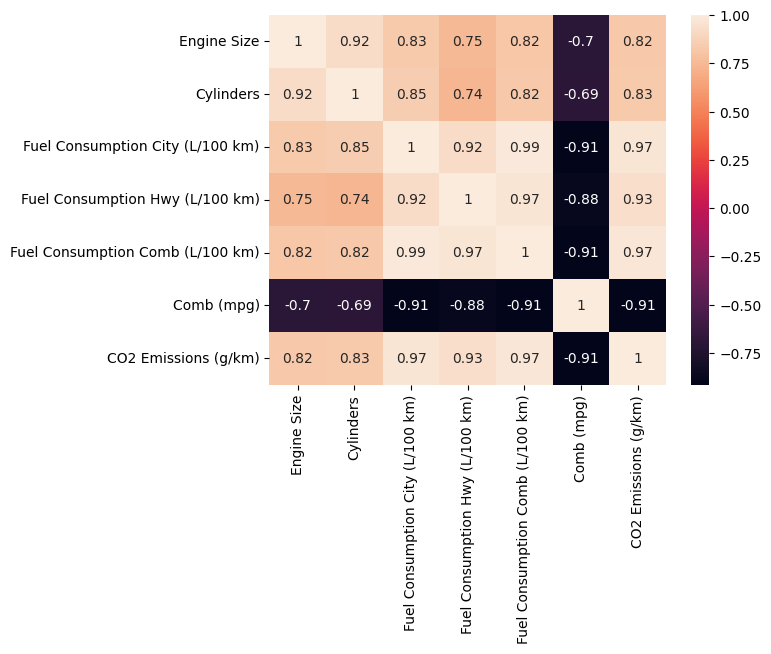

In [29]:
#selecionar apenas as colunas numéricas
dados_num=dados.select_dtypes(include='number')
sns.heatmap(dados_num.corr(), annot = True)

Na última linha (ou coluna) o mapa revela a existência de correlações fortes entre todos os  atributos numéricos  e as emissões de CO2, pois são todas superiores a 0,8 (em valor absoluto). Podemos esperar, portanto, que os atributos tenham elevado valor preditivo relativamente às emissões de CO2.


Uma vez que queremos utlizar estes dados para criar modelos de **regressão linear** para prever as emissões de CO2, é aconselhável verificar primeiro se a relação entre as características e o alvo é do tipo linear.

Para isso, vamos usar o tipo de gráficos **`pairplot`** , da biblioteca **`seaborn`**, cuja saída é uma matriz que contém na diagonal principal o histograma de cada caraterística  e fora da diagonal principal os gráficos dispersão (***scatter***) entre os vários pares de caractrística.

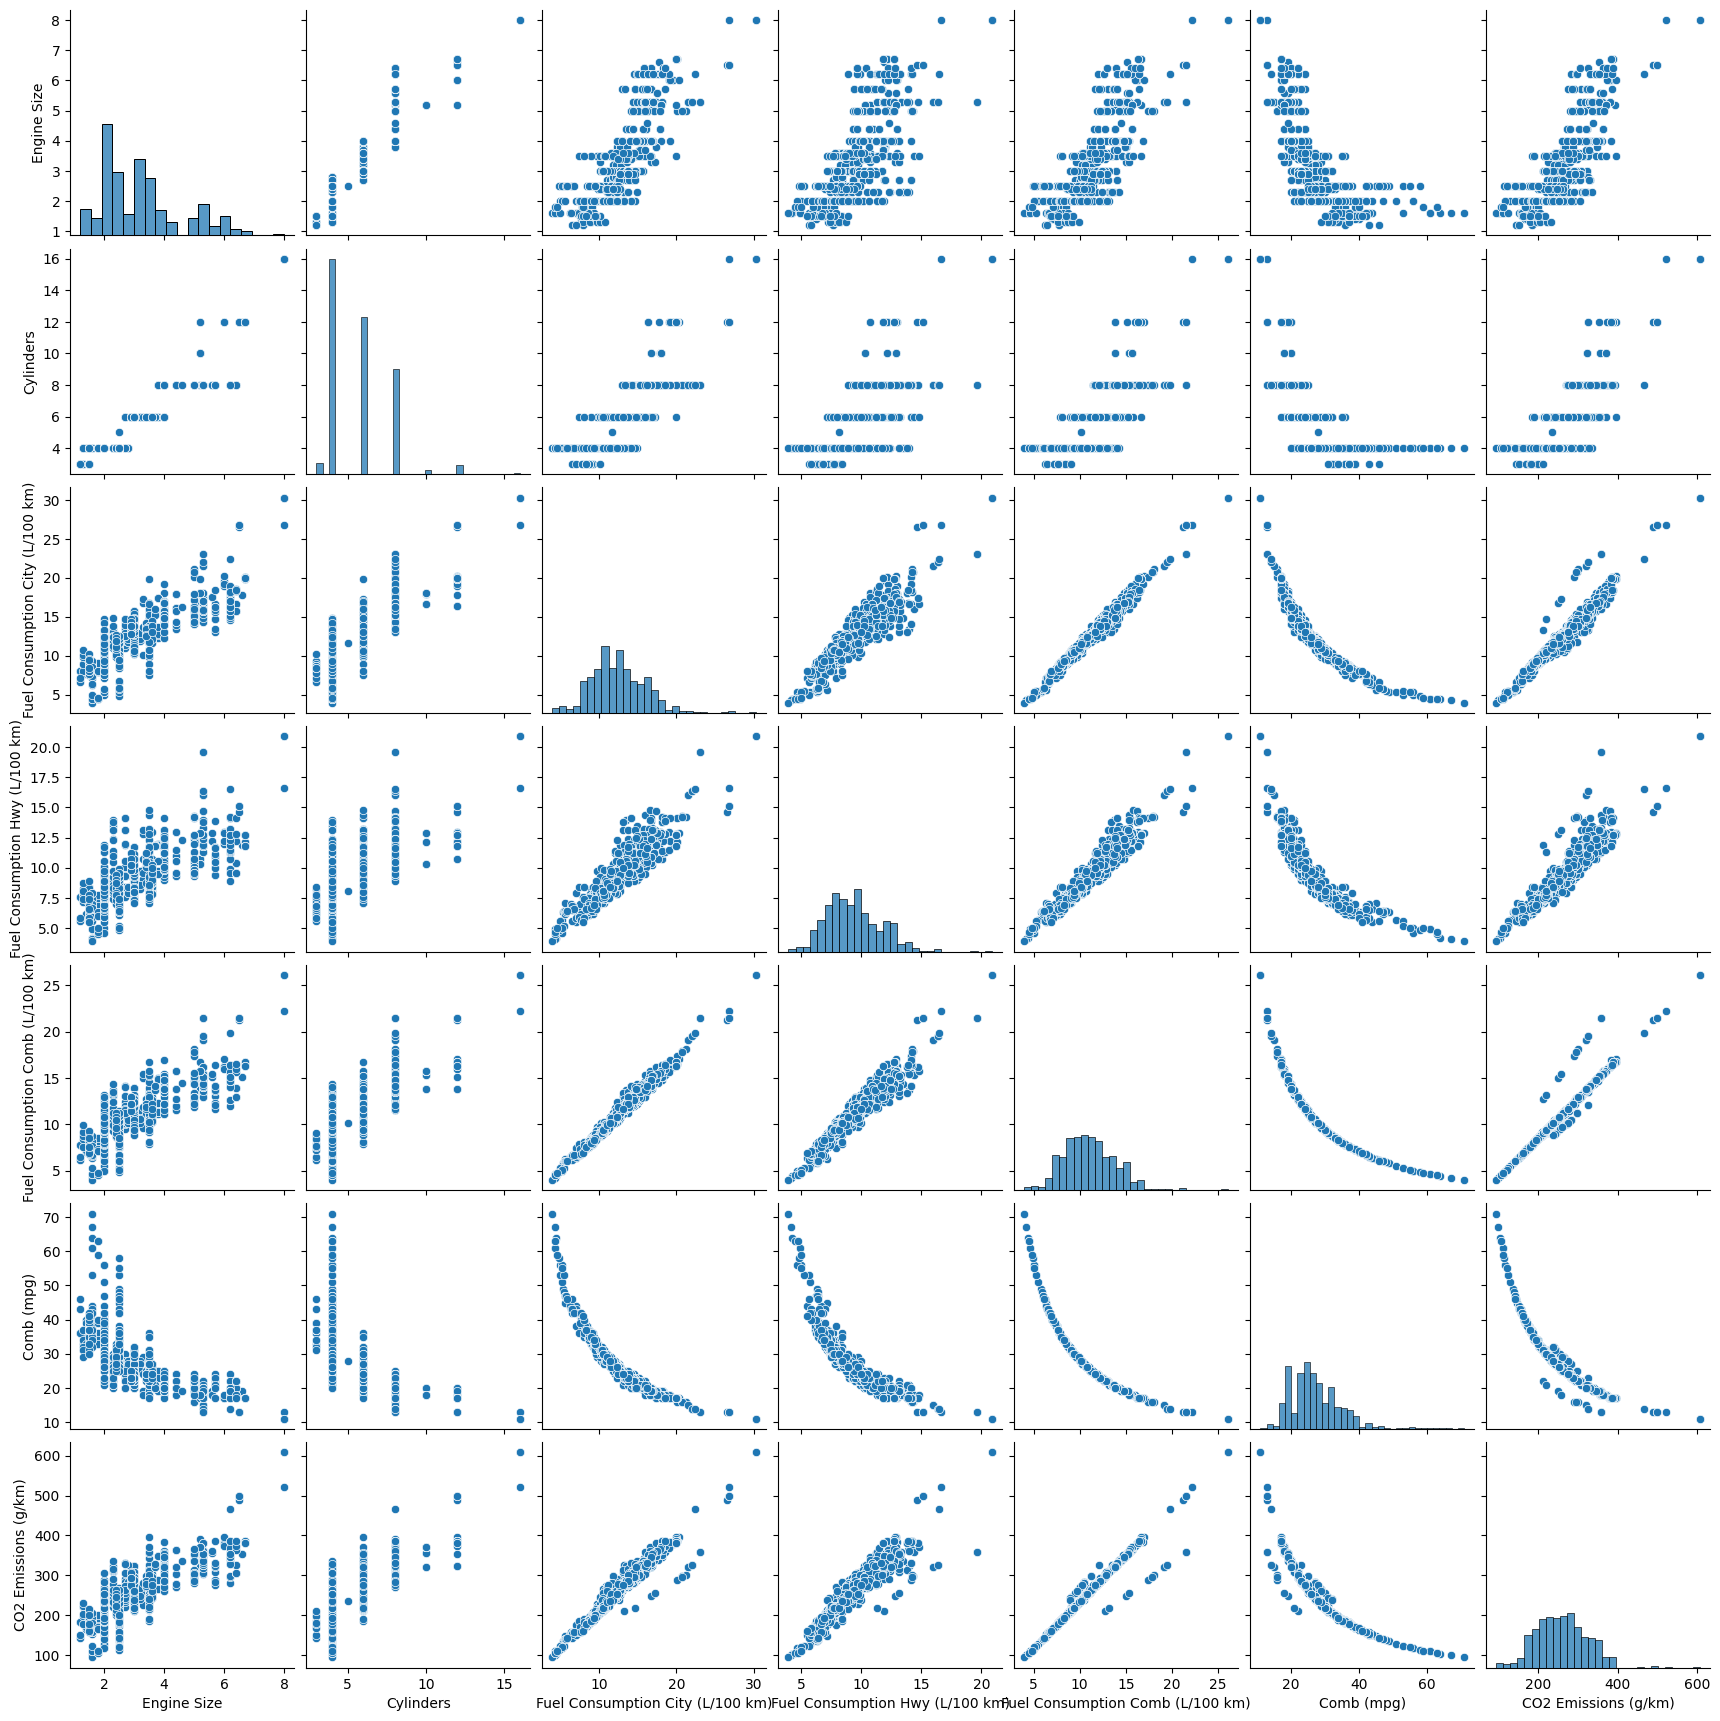

In [30]:
sns.pairplot(dados)

Os gráficos apresentados na última coluna (e na última linha) representam a relação existente entre os atributos e o alvo que queremos considerar - as emissões de CO2.  
À exceção do atributo *Comb (mpg)*  - consumo combinado em *miles per galon* - todos apresentam uma relação linear com o alvo.


## Regressão linear e polinomial

Uma das técnicas mais simples utilizadas para regressão é a **regressão linear**. Entre as vantagens da regressão linear, para além da sua simplicidades,  inclui-se o facto de não ser necessário proceder a optimização de parâmetros.

A regressão linear pode ser classificada relativamente ao número de variáveis dependentes (alvo), Y, como **simples**  ou **multivariada**.  A regressão é simples quando se pretende prever o valor de uma única variável alvo, e multivariada quando se pretende prever o valor de várias variáveis alvo.  
Pode-se ainda distinguir a regressão linear relativamente ao número de variáveis independentes X:
* **Simples**, quando existe apenas uma variável independente, $X$, ou seja, um atributo. A relação entre a variável dependente $Y$ e a variável independente $X$ é dada por $$ Y = \theta_0 + \theta_1 X  $$  
onde $b_0$ é a interceção e $b_1$ é o declive da reta.
*  **Múltipla** quando existem várias variáveis independentes, $(X_1, X_2, \dots, X_N)$. Neste caso, o modelo representa um hiperplano num espaço multidimensional, com a equação $$ Y = \theta_0 + \theta_1 X_1 + \theta_2 X_2 + \dots + \theta_N X_N $$.  Cada um dos coeficientes $(\theta_1, \theta_2, \dots, \theta_N)$ representa o peso da respetiva variável no modelo.

Em seguida aborda-se o problema de regressão linear simples, usando primeiro apenas um atributo dos dados, e depois um conjunto de caracterísitcas (regressão linear múltipla).     
Aborda-se também o problema de **regressão polinomial**, usando um atributo que não se relaciona de forma linear com o alvo.  
Por fim, cria-se um modelo global usando todas as *features* numéricas.

  

## Regressão linear simples ( um atributo )
Como abordagem inicial, vai-se usar apenas um atributo dos dados para treinar um modelo de regressão linear para prever as emissões de CO2.    Para isso, vamos escolher um atributo que tenha uma relação aparente lienar com o alvo. Por exemplo, **Engine Size**.



### Regressão linear com um atributo - definir y e X
O **alvo**, ou variável dependente, $y$, é o campo ***CO2 Emissions (g/km)***. Definimos o
alvo selecionando a respetiva coluna, da seguinte forma:



In [31]:
y=dados[["CO2 Emissions (g/km)"]]
y.head()

,CO2 Emissions (g/km)
0,200
1,263
2,232
3,242
4,230


A variável independente, ou X, será *Engine Size*, que fica definida da seguinte forma:

In [32]:
X=dados[["Engine Size"]]
X.head()

,Engine Size
0,2.4
1,3.5
2,2.0
3,2.0
4,2.0


### Regressão linear com um atributo: definir subconjuntos de treino e de teste


Para proceder à criação de um modelo de aprendizagem automática, os dados disponíveis devem ser divididos em dois **subconjuntos** que são mutuamente exclusivos: **treino** e **teste**.

O subconjunto de treino será usado para treinar o modelo, e o subconjunto de teste será usado para testar o modelo.
Como o subconjunto de teste não faz parte dos dados usados para treinar o modelo, este, uma vez treinado, não conhece qual é a resposta verdadeira para os dados de teste. Assim esse subconjunto  permite uma avaliação do comportamento do modelo criado.

Para separar os dados em conjunto de treino e em conjunto de teste,  a biblioteca *scikit learn* possui a classe **`train_test_split`** que permite fazer essa divisão aleatória de forma simples e eficaz. A documentação encontra-se [aqui](/https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html).

A saída do método é um tuplo que contém, por esta ordem,
* os dados para treino;
* os dados para teste;
* o alvo de treino;
* o alvo de teste.  
É necessário fornecer ao método o X e o y definidos.

Nas opções, usamos `random_state = 0` (ou qualquer outro inteiro), para garantir que os resultados são reprodutíveis.  
Usamos a razão 80% / 20% (80% dos dados para treino, 20% dos dados para teste), que é aceite como padrão para um conjunto de  pequena dimensão, como o atual.

In [33]:
from sklearn.model_selection import train_test_split
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y,
                                              train_size=0.8, test_size=0.2,
                                               random_state=0)

In [34]:
#Verificar a forma das variáveis independentes:
#Como só usamos um atributo,
#neste caso os X só possuem uma coluna.
#o número de linhas corresponde à divisão 80%/20%
print(Xtrain.shape)
print(Xtest.shape)


(756, 1)
(190, 1)


In [35]:
#Verificar a forma das variáveis dependentes
#O alvo é só um, logo os y terão sempre apenas  uma coluna
print( ytrain.shape)
print( ytest.shape)

(756, 1)
(190, 1)


### Regressão linear com um atributo - treinar o modelo e visualizar os parâmetros




Para criar o modelo de regressão linear simples, é necessário  importar o pacote ***linear_model***, de *scikit-learn*.    

Em seguida, define-se o modelo a usar -  **`LinearRegression`**, construíndo o objeto onde o modelo vai ser armazenado.   
O algoritmo implementado em LinearRegression é o dos **mínimos quadráticos** - isto é, baseia-se na minimização da distância entre os valores  gerados pelo modelo e os valores reais.   

O método `fit()` é utilizado para ajustar, no conjunto de treino, a varíavel independente à variável dependente. Este passo corresponde ao **treino do modelo**.

O resultado do ajuste do modelo (`fit`) inclui os parâmetros do modelo, que neste caso são apenas dois - o declive (ou coeficiente) e a ordenada na origem (ou intersecção).

In [36]:
from sklearn import linear_model
#contruir o objeto e definir o algoritmos a usar para construir o modelo
modelo = linear_model.LinearRegression()
# treinar o modelo com os dados de treino e a variável alvo
modelo.fit (Xtrain, ytrain)

print("----- Parâmetros do modelo -------")
#A regressão linear simples só possui um coeficiente,
#que corresponde ao declive da reta
print ('Declive: ', modelo.coef_)
# o outro parâmetro é o parâmetro livre, ou ordenada na origem
print ('Ordenada na origem: ',modelo.intercept_)

----- Parâmetros do modelo -------
Declive:  [[39.08539893]]
Ordenada na origem:  [134.19531482]


Ou seja, obtivemos o seguinte  modelo:

In [37]:
print (f"{y.columns[0]}= {modelo.coef_[0][0]:.2f} * {X.columns[0]} + {modelo.intercept_[0]:.2f}")

CO2 Emissions (g/km)= 39.09 * Engine Size + 134.20


Como apenas trabalhamos com um atributo, pode-se visualizar o resultado da regressão sobreposta aos dados de treino:

Text(0.5, 1.0, 'Regressão linear simples')

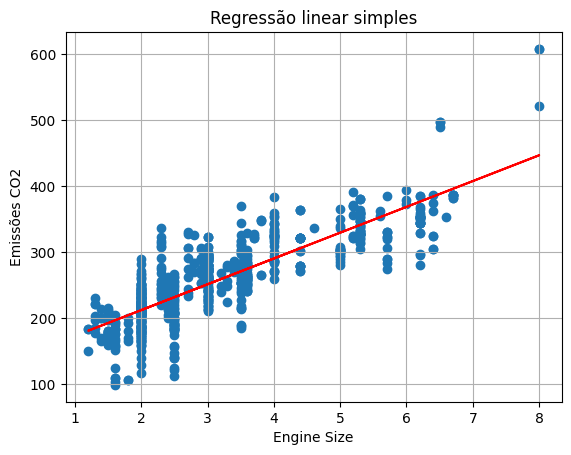

In [38]:
fig, ax = plt.subplots()
ax.grid()
#gráfico de dispersão do alvo em função da feature
ax.scatter(Xtrain["Engine Size"], ytrain["CO2 Emissions (g/km)"] )
#sobrepor ao grafico o modelo (em vermelho)
ax.plot(Xtrain, modelo.coef_[0][0]*Xtrain + modelo.intercept_[0], '-r')  #linha com o modelo
ax.set_xlabel("Engine Size")
ax.set_ylabel("Emissões CO2")
ax.set_title ("Regressão linear simples")

O método `score()` de um objeto `LinearRegression` devolve o coeficente de determinação ($R^2$).  
Fornecendo como parâmetros os  **dados e alvo de treino**, obtém-se $R^2$ para os dados de treino:

In [39]:
print(f"R2 para conjunto de treino: {modelo.score(Xtrain,ytrain):.2f}")

R2 para conjunto de treino: 0.69


Verificamos que efetivamente a reta do modelo se ajusta bem à maioria dos dados de treino.  
Mas como se comportará o modelo com dados que desconhece - os dados de treino?

### Regressão linear  - avaliar o modelo

Para avaliar a **qualidade do modelo** criado, é necessário obter as **previsões** para os dados de teste.  
Isto é feito recorrendo ao método **`predict`**.  


In [40]:
 #Gerar as previsões para os dados de teste
ypred= modelo.predict(Xtest)


Em seguida, é necessário **comparar** essas previsões com os **valores  verdadeiros** da variável alvo.   

Cada tipo de modelo é avaliado com uma métrica adequada. No caso da **regressão**, é comum avaliar-se o modelo recorrendo às seguintes métricas:
*  **erro absoluto médio**  - **MAE**  (do inglês *Mean Absolute Error*);
*  **erro quadrático médio**  - **MSE** (do inglês *Mean Squarred Error*);
*  **raiz do erro quadrático médio** -  **RMSE** (do inglês *Root Mean Squarred Error*);
*  $R^2$, ou **coeficiente de determinação**.

O modelo é tanto melhor quanto menor forem as duas primeiras métricas e quanto  mais próximo de 1 for o valor de $R^2$.



#### Função e DF auxiliares

NEsta faze, é útili criar um data frame para registar as métricas dos vários modelos que serão criados

In [41]:
performance = pd.DataFrame(columns=["train R2", "test R2", "MAE", "RMSE"])

Em seguida definimos a função calcula_metricas() para determinar MAE, RMSE e $R^2$

In [42]:
#importar as classes relevantes
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

def calcula_metricas(nome_do_modelo, r2_treino, ytest, ypred):
    ''' Função que calcula as métricas de avaliação de um modelo de regressão.
        Recebe a designação do modelo, a variável alvo  e as previsões
        e determina as métricas mae, rmse e coeficiente de determinação, R2.
        Por fim, atualiza o DF de performance com os resultados.
    '''
    mae = mean_absolute_error( ytest, ypred )
    rmse = mean_squared_error( ytest, ypred)**0.5 #raiz quadrada de mse
    r2 = r2_score( ytest, ypred )
    print(f"Erro  absoluto médio  = {mae:.2f}")
    print(f"Raiz do erro  quadrático médio  = {rmse:.2f}")
    print(f"Teste: r2: {r2:.2f}")
    #atualizar pd performance
    performance.loc[nome_do_modelo,["train R2", "test R2", "MAE", "RMSE"]]= [f'{r2_treino:.2f}',
                                         f'{r2:.2f}', f'{mae:.2f}', f'{rmse:.2f}']



Nesta fase, é também útil criar um DataFrame para registar as métricas dos modelos que vão ser criados.

#### Determinação das métricas

In [43]:
#determinar R2 de treino
r2_treino = modelo.score(Xtrain,ytrain)
#determinar as métricas de teste
calcula_metricas("regressão linear simples",r2_treino, ytest, ypred)
performance

Erro  absoluto médio  = 28.78
Raiz do erro  quadrático médio  = 37.14
Teste: r2: 0.61


,train R2,test R2,MAE,RMSE
regressão linear simples,0.69,0.61,28.78,37.14


O $R^2$ tem um valor bastante próximo de 1; o MAE tem um valor muito baixo, quando comparado com a escala do alvo (100 - 600).  
Assim, trata-se de um modelo bastante bom.
Será possível melhorá-lo usando mais atributos?

## Regressão linear múltipla



Vimos antes que todos os restantes atributos numéricos,  à exceção de *Comb (mpg)* apresentam uma relação de linearidade com o alvo. Assim, pode-se criar um modelo de regressão linear usando esse conjunto de atributos.

O processo é semelhante ao anterior, apenas variando no conjunto de dados usados para treinar o modelo. E, claro, sendo o modelo gerado mais complexo,  os parâmetros do modelo também são em maior número.  

In [74]:
#Criar subconjunto apenas com dados numéricos
Xmulti = dados[dados.select_dtypes('number').columns].copy()
#Apagar o alvo e o atributo sem relação linear, 'Comb (mpg)'
Xmulti.drop(['CO2 Emissions (g/km)', 'Comb (mpg)', "Fuel Consumption Comb (L/100 km)"], axis=1, inplace=True)
display(Xmulti.head())

,Engine Size,Cylinders,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km)
0,2.4,4,9.9,7.0
1,3.5,6,12.6,9.4
2,2.0,4,11.0,8.6
3,2.0,4,11.3,9.1
4,2.0,4,11.2,8.0


In [75]:
Xmulti.describe()

,Engine Size,Cylinders,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km)
count,946.000000,946.000000,946.000000,946.000000
mean,3.198732,5.668076,12.506448,9.363319
std,1.374814,1.932670,3.452043,2.285125
min,1.200000,3.000000,4.000000,3.900000
25%,2.000000,4.000000,10.200000,7.700000
50%,3.000000,6.000000,12.200000,9.200000
75%,3.800000,6.000000,14.700000,10.700000
max,8.000000,16.000000,30.300000,20.900000


O y permanece igual ao exemplo da regressão simples.

In [76]:
#gerar subconjuntos de teste e de treino
Xmulti_train, Xmulti_test, ytrain, ytest = train_test_split(Xmulti, y,
                                                      train_size=0.8, test_size=0.2,
                                                      random_state=0)

In [77]:
#treinar o modelo
reg_multi = linear_model.LinearRegression()
reg_multi.fit (Xmulti_train, ytrain)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [78]:
print(f"Treino: r2 =  {reg_multi.score(Xmulti_train,ytrain):.2f}")

Treino: r2 =  0.94


In [81]:
#ordenada na origem
reg_multi.intercept_

array([22.13558728])

In [82]:
reg_multi.coef_

array([[ 0.93324658,  3.49522926, 10.62911713,  8.65055319]])

Cada um dos coeficientes no vetor representa o peso da respetiva característica no modelo.  
O modelo pode ser representado pela seguinte equação:

In [83]:
features = Xmulti_train.columns
print (f"{y.columns[0]}= {(reg_multi.intercept_[0]):.2f} + ")
for i, j in zip(features, reg_multi.coef_[0]):
  print(f"+ {i}*{j:.2f}")

CO2 Emissions (g/km)= 22.14 + 
+ Engine Size*0.93
+ Cylinders*3.50
+ Fuel Consumption City (L/100 km)*10.63
+ Fuel Consumption Hwy (L/100 km)*8.65


É interessante verificar que os atributos que apresentam maior coeficiente de correlação com o alvo, conforme verificado no mapa de correlações, são aquelas que possuem os coeficientes mais elevados no modelo.  
Da mesma forma, os atributos com menor correlação linear com o alvo (*Engine Size* e *Cylinders*) são também os que têm menor peso no modelo.  

Vejamos agora a qualidade do modelo, gerando as predições com os dados de teste e calculando as métricas adequadas.

In [85]:
#determinar R2 de treino
r2_treino = reg_multi.score(Xmulti_train,ytrain)
#aplica o modelo para calcular as previsões
ymulti_pred = reg_multi.predict(Xmulti_test)
#determina as métricas de teste e regista
calcula_metricas("regressão linear múltipla",r2_treino, ytest, ymulti_pred)
performance

Erro  absoluto médio  = 6.28
Raiz do erro  quadrático médio  = 11.33
Teste: r2: 0.96


,train R2,test R2,MAE,RMSE
regressão linear simples,0.69,0.61,28.78,37.14
regressão linear múltipla,0.94,0.96,6.28,11.33
Regressão Polinomial,0.93,0.95,7.55,12.64
modelo regressão global,0.95,0.97,5.67,10.70


A qualidade dos dois modelos não é  significativemente diferente, e este último continua a ser de elevada qualidade. Isto acontece porque  a variável que usámos inicialmente possuia um elevado poder preditivo.   
Não obstante, fica exemplificado o método para treino, teste e avaliação de modelos de regressão linear multipla.


## Regressão linear - observações
Como foi dito antes, o modelo que usamos corresponde à regressão linear mais simples,  por minimização dos mínimos quadráticos. Apesar do modelo ser simples, conduz a resultados adequados, e serve o propósito de exemplificar a criação, treino, teste e avaliação de um modelo. Este processo é nuclear mesmo quando se utilizam modelos mais complexos.

Em *scikit learn* estão também implementados outros modelos de regressão linear mais elaborados, que incluem termo de regularização, dos quais se destacam a regressão **LASSO** (documentação [aqui](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html#sklearn.linear_model.Lasso)) e a regressão de **RIDGE** (documentação [aqui](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html#sklearn.linear_model.Ridge)).





## Regressão Polinomial

Em seguinda exemplifica-se  a criação, treino e teste de um modelo de regressão quando a relação entre as variáveis independentes e o alvo não é linear - **regressão polinomial**.

Os modelos de regressão polinomial utilizam-se quando a relação entre os atributos e a variável alvo não segue uma tendência linear, podendo ser melhor descrita por uma função polinomial de grau $n$ (quadrática, cúbica, etc...).

Tal como a regressão linear, a regressão polinomial pode ser utilizada nas sua formulação apenas com um atributo ou com um conjunto de atributos.

Vamos trabalhar com o atributo que previamente verificámos que não possui uma relação linear com o alvo *Comb (mpg)*, isto é, o consumo combinado em unidades imperiais (*miles per galon*).

In [86]:
#Criar o X; o y mantém-se o mesmo
Xmpg = dados[['Comb (mpg)']]
display(Xmpg.head())
print(Xmpg.shape)

,Comb (mpg)
0,33
1,25
2,29
3,27
4,29


(946, 1)


### Regressão polinomial - transformação dos dados

Em Python, a implementação da regressão polinomial é feita em dois passos. Primeiro, os dados são transformados no seu equivalente linear usando o método `PolynomialFeatures()`, do pacote  `sklearn.preprocessing`.
Uma vez transformados os dados, usa-se a regressão linear para treinar o modelo com os dados transformados.

O seguinte esquema representa a transformação dos dados:
![pf](https://drive.google.com/uc?id=1fp0r1i2lVoKyu-thVkRPre2TxsFQYyO8)


Os dados transformados possuem um número de atributos que depende do grau do polinómio considerado.   
Ou seja, a característica X é desdobrada num conjunto de atributos: $X^0$ (que é sempre 1), $X^1$ (igual aos valores originais da característica), $X^2$, ..., até $X^n$, em que $n$ é o grau do polinómio que se pretende.

Trata-se, por isso, de uma mera transformação de variáveis, em que uma equação polinomial é transformada numa equação linear multipla.

Para melhor se entender esta afirmação, considere-se o exemplo que que $n$=2.  
A equação polinomial de grau 2  possui apenas uma variável,  $X$, mas com termo quadrático, $X^2$.  
>Após a transformação, a equação passa a ter a forma linear:  
>$$a.u + b.v + c$$

>com u = $X^2$  e v=$X$.  
>Ou seja, transformou-se uma equação quadrática numa equação linear, na qual já é adequado usada o modelo de regressão linear.

Aconselha-se a consulta da documentação de sklearn sobre este assunto, [aqui]( https://scikit-learn.org/stable/modules/linear_model.html#polynomial-regression-extending-linear-models-with-basis-functions)



Como se observa na imagem anterior, o passo da transformação polinomial é realizado em dois momentos:

1. Inicializa-se o modelo usando **`PolynomialFeatures(n)`**, que tem como parâmetro `n` o grau do polinómio que vai ser utilizado no modelo.
2. Utiliza-se o método **`fit_transform()`**, que calcula e transforma os dados a usar no modelo.Este método devolve um *n-array* Numpy que contém os dados transformados, como explicado acima.

In [54]:
from sklearn.preprocessing import PolynomialFeatures

#Modelo de regressão polinomial
# 1.Aplicar a transformação polinomial aos dados.
#Definir o modelo do polinómio, indicando o grau do polinómio:
pf = PolynomialFeatures(degree=2)
#Aplicar o modelo para transformar Xcomb :
Xpoli = pf.fit_transform(Xmpg)

A saída do `fit_transform` é um array numpy, que pode ser transformado num DataFrame:  

In [87]:
Xpoli =  pd.DataFrame(Xpoli, index=X.index, columns=["mpg^0", "mpg^1", "mpg^2"])
Xpoli.head()

,mpg^0,mpg^1,mpg^2
0,1.0,33.0,1089.0
1,1.0,25.0,625.0
2,1.0,29.0,841.0
3,1.0,27.0,729.0
4,1.0,29.0,841.0


Verifica-se que os valores da primeira coluna são sempre 1 (`Comb(mpg)`$^0$=1), os valores da segunda coluna são os mesmos da coluna `Comb(mpg)` dos dados originais, e os da terceira coluna são os valores de `Comb(mpg)`  elevados ao quadrado.


### Regressão polinomial - treino e teste do modelo

Com os dados estão transformados, o restante processo de treino e teste do modelo é semelhante ao que foi realizado anteriormente.

In [88]:
# 1. criar o subconjunto de treino e teste com os dados já transformados
Xpoli_train, Xpoli_test, ytrain, ytest = train_test_split(Xpoli, y, train_size=.8,
                                                         test_size=.2, random_state = 0)
#2. Aplicar o modelo linear aos dados transformados
pol_reg = linear_model.LinearRegression()
pol_reg.fit(Xpoli_train, ytrain)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [89]:
#determinar R2 de treino
r2_treino = pol_reg.score(Xpoli_train,ytrain)
# 3. Previsão
ypoli_pred = pol_reg.predict(Xpoli_test)

# 4. Avaliação do modelo
calcula_metricas("Regressão Polinomial",r2_treino, ytest, ypoli_pred)
performance


Erro  absoluto médio  = 7.55
Raiz do erro  quadrático médio  = 12.64
Teste: r2: 0.95


,train R2,test R2,MAE,RMSE
regressão linear simples,0.69,0.61,28.78,37.14
regressão linear múltipla,0.94,0.96,6.28,11.33
Regressão Polinomial,0.93,0.95,7.55,12.64
modelo regressão global,0.95,0.97,5.67,10.70


### Regressão polinomial - visualização do modelo


Para melhor visualizar o modelo sobreposto aos dados, será criado um DataFrame com os dados de Xtest e as previsões.  
A variável devolvida pelo método de predição é um np.array, pelo que é necessário transformá-la num DataFrame. O índice é o mesmo do  Xtest.  
Em seguida, a coluna das predições é adicionada ao DataFrame Xtest através do método `join` (para usar este método é fundamental que os índices coincidam)

In [92]:
#transformar predições em DataFrame e atribuir mesmo índice de Xpoly_test
ypoli_pred = pd.DataFrame(ypoli_pred, index=Xpoli_test.index, columns=["ypoly_pred"])
ypoli_pred.head()

,ypoly_pred
869,172.004337
935,192.027075
657,260.985302
362,251.127458
255,281.762190


In [93]:
Xpoli_test.head()

,mpg^0,mpg^1,mpg^2
869,1.0,37.0,1369.0
935,1.0,34.0,1156.0
657,1.0,26.0,676.0
362,1.0,27.0,729.0
255,1.0,24.0,576.0


In [ ]:
#Criar  DF com dados, ytest  e predições
#para usar no gráfico
#1 - retirar as colunas que não interessam
out = Xpoli_test.drop(["mpg^0", "mpg^2"], axis=1)
#2 - incluir os y verdadeiros (de teste)
out = out.join(ytest)
#3 - incluir as previsões
out = out.
(ypoli_pred)
out.head()

,mpg^1,CO2 Emissions (g/km),ypoly_pred
869,37.0,178,172.004337
935,34.0,193,192.027075
657,26.0,256,260.985302
362,27.0,249,251.127458
255,24.0,279,281.762190


In [96]:
#ordenar de acordo com os valores de consumo,
#que vão ser representados no eixo horizontal do gráfico de dispersão
out.sort_values(by="mpg^1", inplace=True)
out.head()

,mpg^1,CO2 Emissions (g/km),ypoly_pred
833,14.0,465,406.870621
317,16.0,298,379.019070
337,17.0,395,365.623894
406,17.0,381,365.623894
65,17.0,383,365.623894


In [62]:
r2=r2_score(ytest, ypoli_pred)

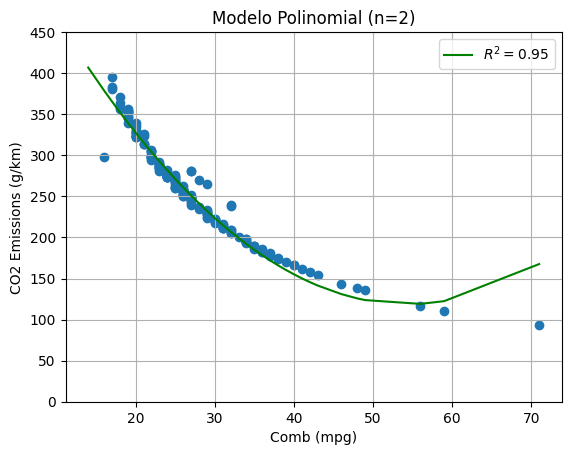

In [63]:
fig, ax = plt.subplots()
ax.grid()
#gráfico de dispersão entre o consumo combinado e as emissões
ax.scatter(out["mpg^1"],out["CO2 Emissions (g/km)"])
#linha com o modelo
ax.plot(out["mpg^1"], out["ypoly_pred"], '-g', label="$R^2={:.2f}$".format(r2))
ax.set_xlabel("Comb (mpg)")
ax.set_ylabel("CO2 Emissions (g/km)")
ax.set_title("Modelo Polinomial (n=2)")
ax.set_ylim(0, 450)
ax.legend()

O gráfico deixa claro que o modelo se ajusta razoavelmente bem aos dados, excepto para os valores mais elevados de consumo.

Fica o desafio: que ordem de polinómio poderia ser mais adequado?

## Regressão linear - modelo global

Tendo verificado que um modelo polinomial de grau n=2 com a característica *"Comb (mpg)"* se adequa razoavelmente bem, podem-se juntar todas os atributos numéricas e criar um modelo global.

Para isso, o X deve conter as colunas numéricas inicias, às quais deve ser retidado a coluna do consumo em mpg, e adicionadas as colunas transformadas pelo `PolinomialFeatures()`.

A partir daí, deve-se proceder com os passos para a criação do modelo de regressão linear.



In [97]:
#voltar à variável Xmulti
Xmulti.head()

,Engine Size,Cylinders,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km)
0,2.4,4,9.9,7.0
1,3.5,6,12.6,9.4
2,2.0,4,11.0,8.6
3,2.0,4,11.3,9.1
4,2.0,4,11.2,8.0


In [98]:
Xpoli.head()

,mpg^0,mpg^1,mpg^2
0,1.0,33.0,1089.0
1,1.0,25.0,625.0
2,1.0,29.0,841.0
3,1.0,27.0,729.0
4,1.0,29.0,841.0


In [99]:
#juntar Xpoly a Xtotal
Xtotal=Xmulti.join(Xpoli)
display(Xtotal.head())
print(Xtotal.shape)

,Engine Size,Cylinders,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),mpg^0,mpg^1,mpg^2
0,2.4,4,9.9,7.0,1.0,33.0,1089.0
1,3.5,6,12.6,9.4,1.0,25.0,625.0
2,2.0,4,11.0,8.6,1.0,29.0,841.0
3,2.0,4,11.3,9.1,1.0,27.0,729.0
4,2.0,4,11.2,8.0,1.0,29.0,841.0


(946, 7)


In [100]:
#subconjuntos de treino e de teste
Xtotal_train, Xtotal_test, ytrain, ytest = train_test_split(Xtotal, y, train_size=.8,
                                                            test_size=.2, random_state=0)
print(Xtotal_train.shape)

(756, 7)


In [102]:
#treinar o modelo
modelo_global = linear_model.LinearRegression()
modelo_global.fit (Xtotal_train, ytrain)
print(modelo_global.intercept_)
print(modelo_global.coef_)


[217.49346268]
[[ 7.74016772e-02  5.43318445e+00  5.54340065e+00  5.83540375e+00
  -2.22044605e-16 -5.20544627e+00  3.53057628e-02]]


O modelo criado é da forma:

In [107]:
features = Xtotal_train.columns
print (f"{y.columns[0]}= {modelo_global.intercept_[0]:.2f}")
for i, j in zip(features, modelo_global.coef_[0]):
  print(f"+ {i}*{j:.2f}")

CO2 Emissions (g/km)= 217.49
+ Engine Size*0.08
+ Cylinders*5.43
+ Fuel Consumption City (L/100 km)*5.54
+ Fuel Consumption Hwy (L/100 km)*5.84
+ mpg^0*-0.00
+ mpg^1*-5.21
+ mpg^2*0.04


In [110]:
r2_treino= modelo_global.score(Xtotal_train, ytrain)
ypred_total = modelo_global.predict(Xtotal_test)
calcula_metricas("modelo regressão global", r2_treino, ytest, ypred_total)
performance

Erro  absoluto médio  = 5.67
Raiz do erro  quadrático médio  = 10.71
Teste: r2: 0.97


,train R2,test R2,MAE,RMSE
regressão linear simples,0.69,0.61,28.78,37.14
regressão linear múltipla,0.94,0.96,6.28,11.33
Regressão Polinomial,0.93,0.95,7.55,12.64
modelo regressão global,0.95,0.97,5.67,10.71


Obtém-se um modelo com métricas ligeiramente melhores do que os modelos anteriores.

Pode-se visualizar a importância de cada um dos atributos para o modelo criado o gráfico dos valores dos coeficientes.

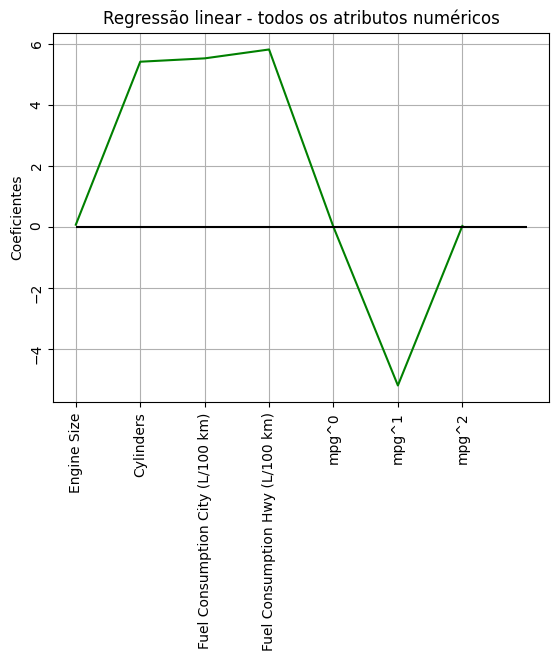

In [111]:
fig, ax = plt.subplots()
ax.plot(Xtotal.columns, modelo_global.coef_[0], color='g')
#traçar linha do 0
ax.hlines(0,0,(len(modelo_global.coef_[0])), 'k')
ax.set_title("Regressão linear - todos os atributos numéricos")
ax.set_ylabel("Coeficientes")
ax.tick_params( labelrotation=90)

ax.grid()

## Material adicional: utilizar Pipelines
Em aprendizagem máquina, é frequente utilizarmos sequências de passos de processamento de dados que podem ser automatizadas. A biblioteca  `scikit-learn` disponibiliza *pipelines* para facilitar essa automatização.  
Existem várias vantagens em utilizar *pipelines*, nomeadamente maior clareza no código, diminuição de erros e maior facilidade em testar modelos.  
Nestas *pipelines* existe sempre um passo de processamento de dados, e um passo de criação do modelo de aprendizagem máquina.

Para criar uma *pipeline*, começa-se por definir a sequência de operações que se pretende automatizar, e que deve conter um **transformador**, seguido de um **modelo**.   
Consegue-se distinguir um transformador de um modelo pela forma como são usados:
* Um transformador usa-se com `transform()` - por exemplo, `fit_transform()`
* Um modelo usa-se com métodos `fit()` e  `predict()`.

A *pipeline* é gerada com **`make_pipeline()`**, de `sklearn.pipeline`.
Uma vez gerada, a pipeline pode ser usada usando `fit()` para aplicar sequencialmente o transformador e o modelo aos dados.





### Optimizar o grau do polinómio com pipelines
Em seguida  exemplifica-se a utilização de pipelines para optimizar o grau do polinómio na regressão polinomial com o atributo *Comb (mpg)*.
O transformador é `PolinomialFeatures(n)` e o modelo é `LinearRegression()`

Usa-se um ciclo `for`  para percorrer uma lista de valores de grau de polinómio e um *pipeline* para a transformaçõo polinomial dos dados, imprimindo a linha de cada modelo gerado.


/tmp/ipykernel_38230/1784247920.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


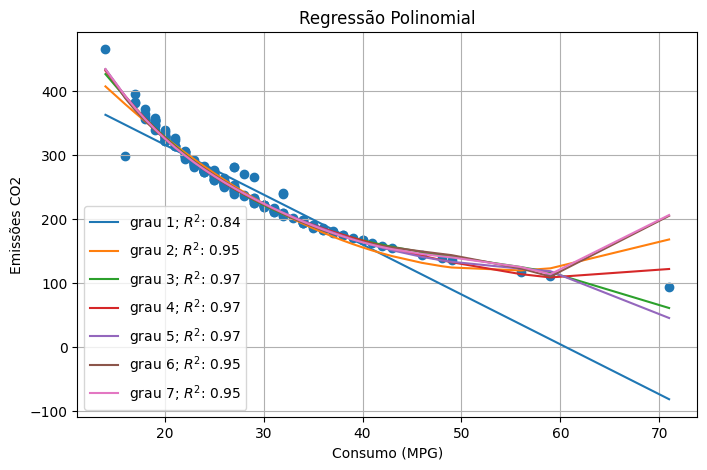

In [116]:
#Regressão polinomial de ordem N
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

#Código para os gráficos
fig, ax = plt.subplots(figsize=(8,5))
ax.scatter(out["mpg^1"],out["CO2 Emissions (g/km)"])
ax.set_title("Regressão Polinomial")
ax.set_xlabel("Consumo (MPG)")
ax.set_ylabel("Emissões CO2")
ax.legend()
ax.grid()

#fazer primeiro separação treino / teste
Xtrain, Xtest, ytrain, ytest = train_test_split(Xmpg, y, train_size=.8,
                                                random_state=0)

for grau in [1,2,3,4,5,6,7]:  #testamos n entre 1 e 7;
  #definir a pipeline - > transformação polinomial seguida de regressão linear
  poli_reg_pipeline = make_pipeline(PolynomialFeatures(grau), LinearRegression())
  #aplicar a pipeline aos dados de treino
  poli_reg_pipeline.fit(Xtrain,ytrain)
  #A instrução seguinte é necessária para que os pontos surjam no plot
  #por ordem  crescente de variável independente ("Consumo(MPG")
  Xtest_sorted=Xtest.sort_values(by="Comb (mpg)")
  #prever usando a pipeline
  y_predict = poli_reg_pipeline.predict(Xtest_sorted)
  R2=poli_reg_pipeline.score(Xtest, ytest)
  ax.plot(Xtest_sorted, y_predict, label="grau %d" % grau +'; $R^2$: %.2f' % R2)
  ax.legend()


Verificamos, portanto, que o valor de  $R^2$  aumenta de 0,84 quando n=1 (corresponde a uma regressão linear) até 0,97 quando n=3, diminuindo a partir de n=6.